# Notebook 05 — Model Training: Random Forest & SVM with Optuna

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives
**Input**: `data/processed/X_train_selected.csv`, `y_train.csv`
**Output**:
- `models/rf_classifier.joblib` — Optimised RF + SMOTE pipeline (fit on full training set)
- `models/svm_classifier.joblib` — Optimised SVM + SMOTE pipeline (fit on full training set)
- `results/model_metrics/cv_scores_nb05.csv` — 5-fold CV metrics

**Optuna search strategy (laptop-practical)**:
- RF: 3 000-sample stratified subsample, 3-fold CV, 30 trials, n_estimators ≤ 500
- SVM: 2 000-sample stratified subsample, 3-fold CV, 20 trials
- Final models fitted on full training set; final CV on 5 000-sample stratified subset

**QC-5**: CV balanced accuracy > 0.70 for best model.

---

In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, sys, joblib
from datetime import datetime

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (StratifiedKFold, StratifiedShuffleSplit,
                                     cross_validate)
from sklearn.metrics import make_scorer, matthews_corrcoef
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

(PROJECT_ROOT / 'models').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'results' / 'model_metrics').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Project root : E:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
Timestamp    : 2026-05-10 09:24


In [2]:
# ============================================================
# CELL 2: Load Feature-Selected Training Data
# ============================================================

DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

X_train = pd.read_csv(DATA_DIR / 'X_train_selected.csv', index_col=0)

y_df    = pd.read_csv(DATA_DIR / 'y_train.csv', index_col=0)
y_train = (y_df['activity_class'] == 'Active').astype(int)

# Align on shared index (guard against any row-order mismatch)
common_idx = X_train.index.intersection(y_train.index)
X_train = X_train.loc[common_idx]
y_train = y_train.loc[common_idx]

n_active   = int(y_train.sum())
n_inactive = len(y_train) - n_active

print(f"X_train shape : {X_train.shape}")
print(f"y_train       : {len(y_train)} samples")
print(f"  Active (1)  : {n_active}  ({n_active/len(y_train)*100:.1f}%)")
print(f"  Inactive (0): {n_inactive}  ({n_inactive/len(y_train)*100:.1f}%)")
assert X_train.shape[0] == len(y_train), "Row count mismatch!"


X_train shape : (9563, 943)
y_train       : 9563 samples
  Active (1)  : 5290  (55.3%)
  Inactive (0): 4273  (44.7%)


In [3]:
# ============================================================
# CELL 3: Stratified Subsamples for Optuna Search
# ============================================================

# ---- RF search subset: 3 000 samples ----
sss_rf = StratifiedShuffleSplit(n_splits=1, train_size=3000, random_state=SEED)
rf_sub_idx, _ = next(sss_rf.split(X_train, y_train))
X_rf_sub = X_train.iloc[rf_sub_idx].values   # numpy for sklearn speed
y_rf_sub = y_train.iloc[rf_sub_idx].values

# ---- SVM search subset: 2 000 samples ----
sss_sv = StratifiedShuffleSplit(n_splits=1, train_size=2000, random_state=SEED)
sv_sub_idx, _ = next(sss_sv.split(X_train, y_train))
X_sv_sub = X_train.iloc[sv_sub_idx].values
y_sv_sub = y_train.iloc[sv_sub_idx].values

# ---- Final evaluation subset: 5 000 samples (used for SVM full CV) ----
sss_ev = StratifiedShuffleSplit(n_splits=1, train_size=5000, random_state=SEED)
ev_sub_idx, _ = next(sss_ev.split(X_train, y_train))
X_ev = X_train.iloc[ev_sub_idx].values
y_ev = y_train.iloc[ev_sub_idx].values

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1'               : 'f1',
    'mcc'              : make_scorer(matthews_corrcoef),
    'roc_auc'          : 'roc_auc',
}

print("Subsamples ready:")
print(f"  RF search   : {X_rf_sub.shape}  (active={y_rf_sub.sum()})")
print(f"  SVM search  : {X_sv_sub.shape}  (active={y_sv_sub.sum()})")
print(f"  Final eval  : {X_ev.shape}      (active={y_ev.sum()})")


Subsamples ready:
  RF search   : (3000, 943)  (active=1660)
  SVM search  : (2000, 943)  (active=1106)
  Final eval  : (5000, 943)      (active=2766)


In [4]:
# ============================================================
# CELL 4: Random Forest — Optuna Optimisation
#         (3 000-sample subsample, 3-fold CV, 30 trials)
# ============================================================

def objective_rf(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth'         : trial.suggest_int('max_depth', 5, 30),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'      : trial.suggest_categorical('max_features',
                                                         ['sqrt', 'log2', 0.3]),
    }
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)),
    ])
    res = cross_validate(pipe, X_rf_sub, y_rf_sub, cv=cv3,
                         scoring='balanced_accuracy', n_jobs=1)
    return res['test_score'].mean()

print(f"Starting RF optimisation (30 trials on 3 000-sample subset) ...")
study_rf = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=30, timeout=1500)

print(f"RF optimisation done  ({len(study_rf.trials)} trials completed)")
print(f"  Best BA (3-fold, subsample): {study_rf.best_value:.4f}")
print(f"  Best params: {study_rf.best_params}")


Starting RF optimisation (30 trials on 3 000-sample subset) ...


RF optimisation done  (30 trials completed)
  Best BA (3-fold, subsample): 0.7274
  Best params: {'n_estimators': 300, 'max_depth': 21, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 0.3}


In [5]:
# ============================================================
# CELL 5: Train Final RF — Full 5-Fold CV + Fit on Full Data
# ============================================================

best_rf = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('rf', RandomForestClassifier(**study_rf.best_params,
                                   random_state=SEED, n_jobs=-1)),
])

print("5-fold CV on full training set (RF) ...")
rf_cv = cross_validate(best_rf, X_train.values, y_train.values,
                       cv=cv5, scoring=scoring, n_jobs=-1)

rf_mean = {k.replace('test_', ''): v.mean()
           for k, v in rf_cv.items() if k.startswith('test_')}
rf_std  = {k.replace('test_', ''): v.std()
           for k, v in rf_cv.items() if k.startswith('test_')}

print("RF 5-Fold CV Results (full data):")
for m, v in rf_mean.items():
    print(f"  {m:<22}: {v:.4f} +/- {rf_std[m]:.4f}")

print("\nFitting final RF on full training set ...")
best_rf.fit(X_train.values, y_train.values)
joblib.dump(best_rf, PROJECT_ROOT / 'models' / 'rf_classifier.joblib')
print("Saved -> models/rf_classifier.joblib")


5-fold CV on full training set (RF) ...


RF 5-Fold CV Results (full data):
  balanced_accuracy     : 0.7582 +/- 0.0083
  f1                    : 0.7763 +/- 0.0078
  mcc                   : 0.5143 +/- 0.0165
  roc_auc               : 0.8435 +/- 0.0095

Fitting final RF on full training set ...


Saved -> models/rf_classifier.joblib


In [6]:
# ============================================================
# CELL 6: SVM — Optuna Optimisation
#         (2 000-sample subsample, 3-fold CV, 20 trials)
# ============================================================

def objective_svm(trial):
    params = {
        'C'      : trial.suggest_float('C', 0.01, 100, log=True),
        'gamma'  : trial.suggest_float('gamma', 1e-4, 1.0, log=True),
        'kernel' : trial.suggest_categorical('kernel', ['rbf', 'linear']),
    }
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('svm', SVC(**params, probability=True, random_state=SEED)),
    ])
    res = cross_validate(pipe, X_sv_sub, y_sv_sub, cv=cv3,
                         scoring='balanced_accuracy', n_jobs=-1)
    return res['test_score'].mean()

print(f"Starting SVM optimisation (20 trials on 2 000-sample subset) ...")
study_svm = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_svm.optimize(objective_svm, n_trials=20, timeout=900)

print(f"SVM optimisation done  ({len(study_svm.trials)} trials completed)")
print(f"  Best BA (3-fold, subsample): {study_svm.best_value:.4f}")
print(f"  Best params: {study_svm.best_params}")


Starting SVM optimisation (20 trials on 2 000-sample subset) ...


SVM optimisation done  (20 trials completed)
  Best BA (3-fold, subsample): 0.7038
  Best params: {'C': 64.59924785978339, 'gamma': 0.002850432062787151, 'kernel': 'rbf'}


In [7]:
# ============================================================
# CELL 7: Train Final SVM — 5-Fold CV on 5k Subset + Full Fit
# ============================================================

best_svm = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('svm', SVC(**study_svm.best_params, probability=True, random_state=SEED)),
])

print("5-fold CV on 5 000-sample evaluation subset (SVM) ...")
svm_cv = cross_validate(best_svm, X_ev, y_ev,
                        cv=cv5, scoring=scoring, n_jobs=-1)

svm_mean = {k.replace('test_', ''): v.mean()
            for k, v in svm_cv.items() if k.startswith('test_')}
svm_std  = {k.replace('test_', ''): v.std()
            for k, v in svm_cv.items() if k.startswith('test_')}

print("SVM 5-Fold CV Results (5k eval subset):")
for m, v in svm_mean.items():
    print(f"  {m:<22}: {v:.4f} +/- {svm_std[m]:.4f}")

print("\nFitting final SVM on full training set (may take several minutes) ...")
best_svm.fit(X_train.values, y_train.values)
joblib.dump(best_svm, PROJECT_ROOT / 'models' / 'svm_classifier.joblib')
print("Saved -> models/svm_classifier.joblib")


5-fold CV on 5 000-sample evaluation subset (SVM) ...


SVM 5-Fold CV Results (5k eval subset):
  balanced_accuracy     : 0.7342 +/- 0.0112
  f1                    : 0.7699 +/- 0.0107
  mcc                   : 0.4715 +/- 0.0229
  roc_auc               : 0.8161 +/- 0.0109

Fitting final SVM on full training set (may take several minutes) ...


Saved -> models/svm_classifier.joblib


In [8]:
# ============================================================
# CELL 8: Save CV Metrics and Optuna Histories
# ============================================================

metrics_dir = PROJECT_ROOT / 'results' / 'model_metrics'

cv_summary = pd.DataFrame([
    {'model': 'RF',
     'n_optuna_trials': len(study_rf.trials),
     'optuna_best_BA' : round(study_rf.best_value, 4),
     **{f'cv_{k}': round(v, 4) for k, v in rf_mean.items()},
     **{f'cv_{k}_std': round(v, 4) for k, v in rf_std.items()}},
    {'model': 'SVM',
     'n_optuna_trials': len(study_svm.trials),
     'optuna_best_BA' : round(study_svm.best_value, 4),
     **{f'cv_{k}': round(v, 4) for k, v in svm_mean.items()},
     **{f'cv_{k}_std': round(v, 4) for k, v in svm_std.items()}},
])
cv_summary.to_csv(metrics_dir / 'cv_scores_nb05.csv', index=False)
print("Saved -> results/model_metrics/cv_scores_nb05.csv")

# Optuna histories
for name, study in [('RF', study_rf), ('SVM', study_svm)]:
    h = study.trials_dataframe()[['number', 'value', 'state']]
    h.columns = ['trial', 'balanced_accuracy', 'state']
    h['model'] = name
    h.to_csv(metrics_dir / f'optuna_history_{name}_nb05.csv', index=False)
print("Saved -> results/model_metrics/optuna_history_*.csv")

hp_df = pd.DataFrame([
    {'model': 'RF',  **study_rf.best_params},
    {'model': 'SVM', **study_svm.best_params},
])
hp_df.to_csv(metrics_dir / 'best_hyperparams_nb05.csv', index=False)
print("Saved -> results/model_metrics/best_hyperparams_nb05.csv")

print()
print(cv_summary[['model', 'optuna_best_BA',
                   'cv_balanced_accuracy', 'cv_f1',
                   'cv_mcc', 'cv_roc_auc']].to_string(index=False))


Saved -> results/model_metrics/cv_scores_nb05.csv
Saved -> results/model_metrics/optuna_history_*.csv
Saved -> results/model_metrics/best_hyperparams_nb05.csv

model  optuna_best_BA  cv_balanced_accuracy  cv_f1  cv_mcc  cv_roc_auc
   RF          0.7274                0.7582 0.7763  0.5143      0.8435
  SVM          0.7038                0.7342 0.7699  0.4715      0.8161


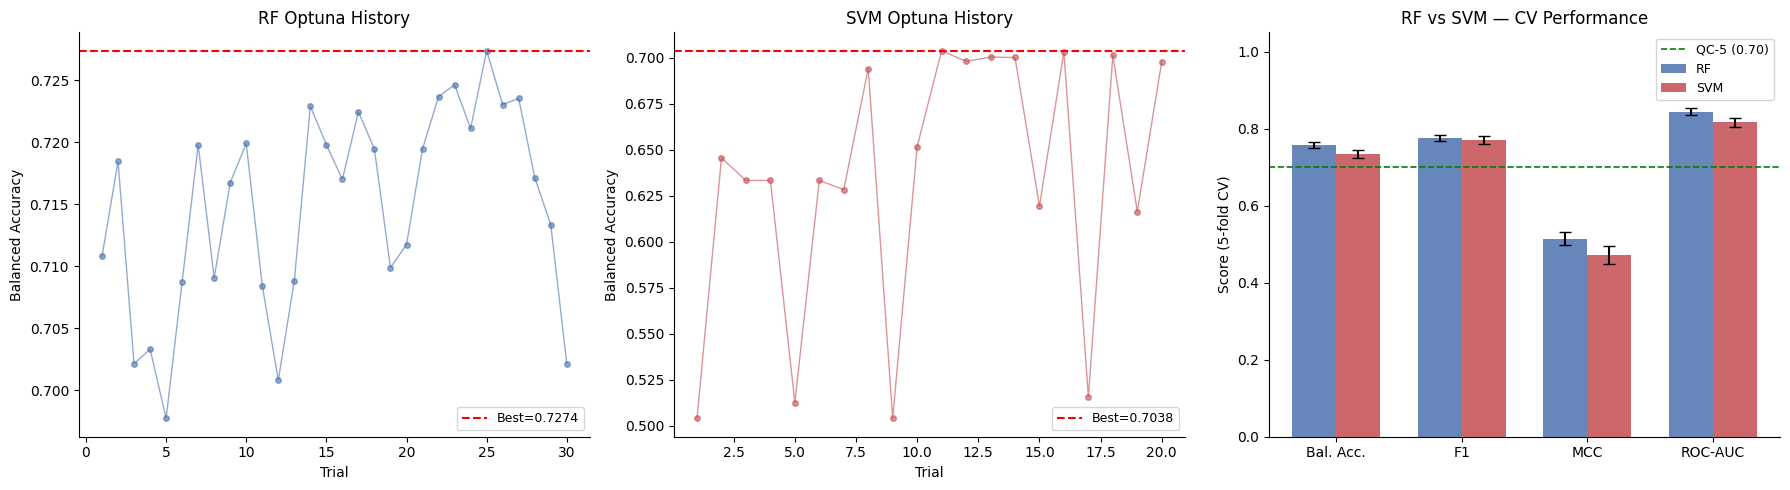

Figure saved -> figures/nb05_training_summary.png


In [9]:
# ============================================================
# CELL 9: Visualisation — Optimisation History & CV Scores
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, study, name, color in [
        (axes[0], study_rf,  'RF',  '#4C72B0'),
        (axes[1], study_svm, 'SVM', '#C44E52')]:
    vals = [t.value for t in study.trials if t.value is not None]
    ax.plot(range(1, len(vals)+1), vals, 'o-', color=color,
            alpha=0.6, markersize=4, linewidth=1)
    ax.axhline(study.best_value, color='red', linestyle='--',
               linewidth=1.5, label=f'Best={study.best_value:.4f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_title(f'{name} Optuna History')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

ax = axes[2]
metrics_plot = ['balanced_accuracy', 'f1', 'mcc', 'roc_auc']
labels = ['Bal. Acc.', 'F1', 'MCC', 'ROC-AUC']
x = np.arange(len(metrics_plot))
w = 0.35
rf_v  = [rf_mean[m]  for m in metrics_plot]
svm_v = [svm_mean[m] for m in metrics_plot]
rf_e  = [rf_std[m]   for m in metrics_plot]
svm_e = [svm_std[m]  for m in metrics_plot]

ax.bar(x - w/2, rf_v,  w, yerr=rf_e,  capsize=4, color='#4C72B0', alpha=0.85, label='RF')
ax.bar(x + w/2, svm_v, w, yerr=svm_e, capsize=4, color='#C44E52', alpha=0.85, label='SVM')
ax.axhline(0.70, color='green', linestyle='--', linewidth=1.2, label='QC-5 (0.70)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Score (5-fold CV)'); ax.set_title('RF vs SVM — CV Performance')
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'nb05_training_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved -> figures/nb05_training_summary.png")


In [10]:
# ============================================================
# CELL 10: QC-5 — Training Quality Checkpoint
# ============================================================

print("=" * 55)
print("QC-5: Model Training Audit")
print("=" * 55)

ba_rf  = rf_mean['balanced_accuracy']
ba_svm = svm_mean['balanced_accuracy']
best_ba = max(ba_rf, ba_svm)

print(f"RF  CV Balanced Accuracy : {ba_rf:.4f} +/- {rf_std['balanced_accuracy']:.4f}")
print(f"SVM CV Balanced Accuracy : {ba_svm:.4f} +/- {svm_std['balanced_accuracy']:.4f}")
print(f"Best model               : {'RF' if ba_rf >= ba_svm else 'SVM'} (BA={best_ba:.4f})")

assert best_ba >= 0.70, f"QC-5 FAILED: best BA {best_ba:.4f} < 0.70"
print(f"QC-5 PASSED (best BA {best_ba:.4f} >= 0.70)")

rf_path  = PROJECT_ROOT / 'models' / 'rf_classifier.joblib'
svm_path = PROJECT_ROOT / 'models' / 'svm_classifier.joblib'
assert rf_path.exists()  and svm_path.exists()
print(f"[OK] rf_classifier.joblib  ({rf_path.stat().st_size//1024} KB)")
print(f"[OK] svm_classifier.joblib ({svm_path.stat().st_size//1024} KB)")

print()
print(f"Best RF  params : {study_rf.best_params}")
print(f"Best SVM params : {study_svm.best_params}")
print("=" * 55)
print("Next: notebook 06 — XGBoost + LightGBM")
print("=" * 55)


QC-5: Model Training Audit
RF  CV Balanced Accuracy : 0.7582 +/- 0.0083
SVM CV Balanced Accuracy : 0.7342 +/- 0.0112
Best model               : RF (BA=0.7582)
QC-5 PASSED (best BA 0.7582 >= 0.70)
[OK] rf_classifier.joblib  (57248 KB)
[OK] svm_classifier.joblib (89039 KB)

Best RF  params : {'n_estimators': 300, 'max_depth': 21, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 0.3}
Best SVM params : {'C': 64.59924785978339, 'gamma': 0.002850432062787151, 'kernel': 'rbf'}
Next: notebook 06 — XGBoost + LightGBM
